ACTIVITY RECOGNITION MODEL TRAINING
TensorFlow version: 2.13.0
GPU available: True

STEP 1: Loading Preprocessed Data
✓ Loaded data
  Training: (2018, 128, 6)
  Test: (347, 128, 6)

Activities:
  0: nail_biting
  1: knuckles_cracking
  2: hand_tapping
  3: sitting

STEP 2: Building CNN Model


2025-11-18 22:19:50.379054: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-11-18 22:19:50.379100: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-18 22:19:50.379108: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-18 22:19:50.379643: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-18 22:19:50.380243: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 128, 32)           608       
                                                                 
 bn1 (BatchNormalization)    (None, 128, 32)           128       
                                                                 
 pool1 (MaxPooling1D)        (None, 64, 32)            0         
                                                                 
 dropout1 (Dropout)          (None, 64, 32)            0         
                                                                 
 conv2 (Conv1D)              (None, 64, 64)            6208      
                                                                 
 bn2 (BatchNormalization)    (None, 64, 64)            256       
                                                                 
 pool2 (MaxPooling1D)        (None, 32, 64)            0

2025-11-18 22:19:51.830259: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


51/51 [==============================] - ETA: 0s - loss: 0.4643 - accuracy: 0.8309

2025-11-18 22:19:57.852532: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


51/51 [==============================] - 7s 38ms/step - loss: 0.4643 - accuracy: 0.8309 - val_loss: 0.9616 - val_accuracy: 0.6832 - lr: 0.0010
Epoch 2/50
51/51 [==============================] - 1s 11ms/step - loss: 0.2172 - accuracy: 0.9250 - val_loss: 0.8638 - val_accuracy: 0.6683 - lr: 0.0010
Epoch 3/50
51/51 [==============================] - 1s 13ms/step - loss: 0.1344 - accuracy: 0.9517 - val_loss: 1.1224 - val_accuracy: 0.6733 - lr: 0.0010
Epoch 4/50
51/51 [==============================] - 1s 13ms/step - loss: 0.1143 - accuracy: 0.9703 - val_loss: 1.2868 - val_accuracy: 0.6856 - lr: 0.0010
Epoch 5/50
51/51 [==============================] - 1s 13ms/step - loss: 0.0958 - accuracy: 0.9647 - val_loss: 1.7618 - val_accuracy: 0.6609 - lr: 0.0010
Epoch 6/50
51/51 [==============================] - 1s 13ms/step - loss: 0.0976 - accuracy: 0.9672 - val_loss: 2.0943 - val_accuracy: 0.6733 - lr: 0.0010
Epoch 7/50
50/51 [============================>.] - ETA: 0s - loss: 0.0982 - accuracy: 

2025-11-18 22:20:05.380394: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Detailed Classification Report:
                   precision    recall  f1-score   support

      nail_biting      1.000     0.988     0.994        81
knuckles_cracking      0.808     1.000     0.894       122
     hand_tapping      1.000     0.701     0.824        77
          sitting      1.000     0.925     0.961        67

         accuracy                          0.916       347
        macro avg      0.952     0.904     0.918       347
     weighted avg      0.932     0.916     0.915       347


STEP 5: Visualizing Results


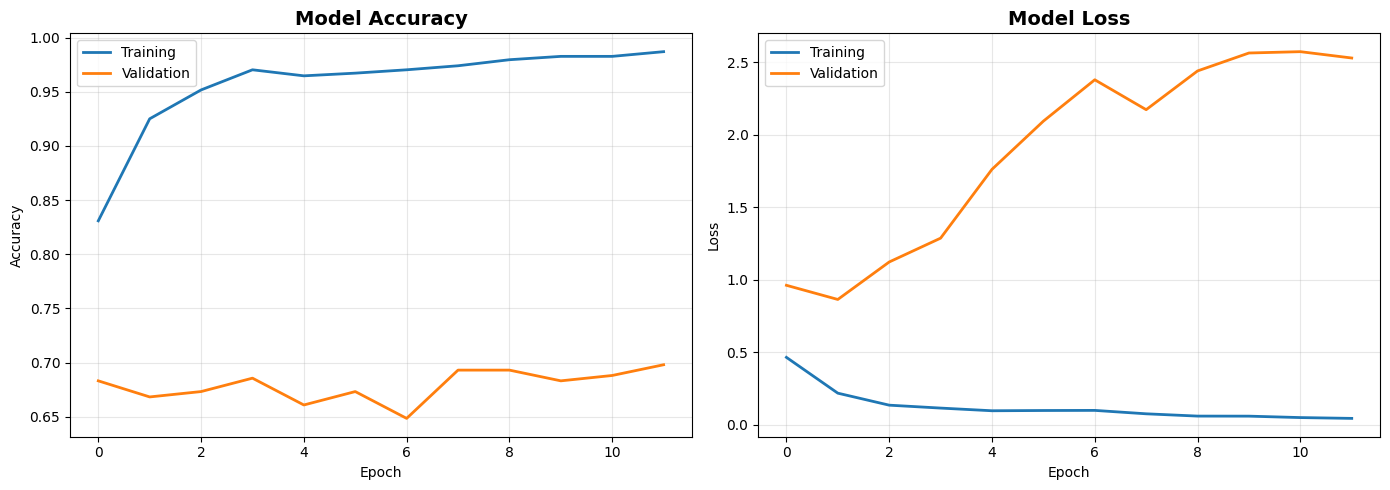

✓ Saved: ../results/training_history.png


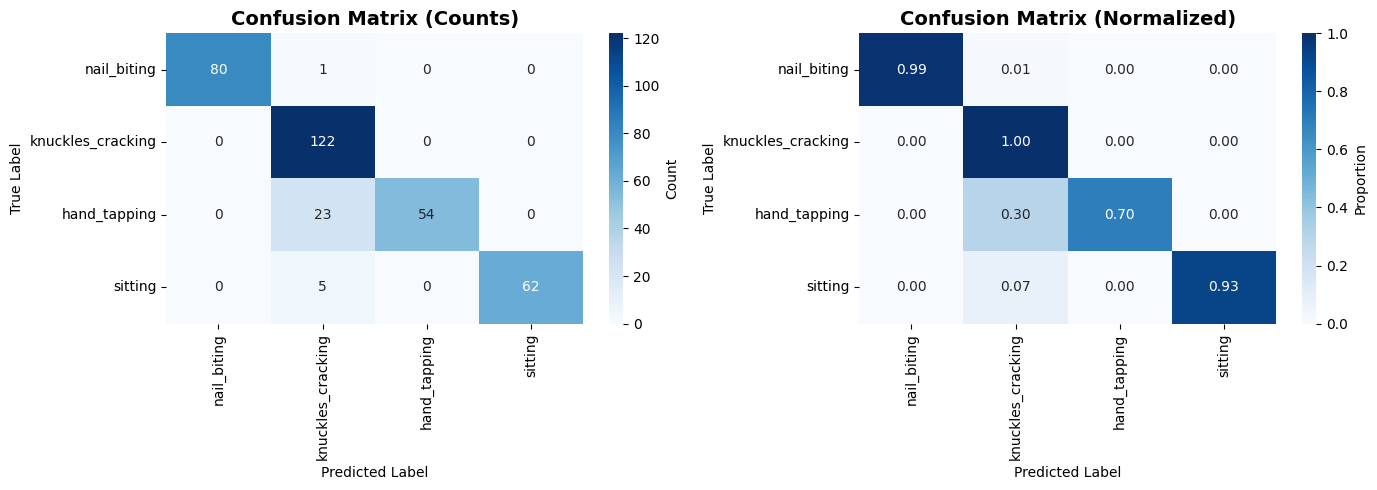

✓ Saved: ../results/confusion_matrix.png

STEP 6: Saving Model
✓ Saved: ../models/activity_model.h5
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.
✓ Saved: ../models/model_architecture.png
✓ Saved: ../models/training_info.pkl

STEP 7: Test Prediction Examples

Sample predictions (first 10 test samples):
  ✗ True: nail_biting          | Predicted: knuckles_cracking    | Confidence:  60.6%
  ✓ True: nail_biting          | Predicted: nail_biting          | Confidence:  80.0%
  ✓ True: nail_biting          | Predicted: nail_biting          | Confidence:  86.5%
  ✓ True: nail_biting          | Predicted: nail_biting          | Confidence:  87.4%
  ✓ True: nail_biting          | Predicted: nail_biting          | Confidence:  84.1%
  ✓ True: nail_biting          | Predicted: nail_biting          | Confidence:  74.0%
  ✓ True: nail_biting          | Predicted: nail_biting          | Confidence

/opt/homebrew/Caskroom/miniforge/base/envs/tinyml/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [5]:
"""
Model Training for Activity Recognition
CNN model optimized for XIAO nRF52840 deployment
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("ACTIVITY RECOGNITION MODEL TRAINING")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ============================================================================
# STEP 1: Load Preprocessed Data
# ============================================================================
print("\n" + "="*60)
print("STEP 1: Loading Preprocessed Data")
print("="*60)

data_dir = Path('../data/processed')

X_train = np.load(data_dir / 'X_train.npy')
y_train = np.load(data_dir / 'y_train.npy')
X_test = np.load(data_dir / 'X_test.npy')
y_test = np.load(data_dir / 'y_test.npy')

with open(data_dir / 'preprocessing_info.pkl', 'rb') as f:
    preprocessing_info = pickle.load(f)

label_to_activity = preprocessing_info['label_to_activity']
config = preprocessing_info['config']

print(f"✓ Loaded data")
print(f"  Training: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"\nActivities:")
for label, activity in label_to_activity.items():
    print(f"  {label}: {activity}")

# ============================================================================
# STEP 2: Build CNN Model (Optimized for Microcontroller)
# ============================================================================
print("\n" + "="*60)
print("STEP 2: Building CNN Model")
print("="*60)

def build_model(input_shape, num_classes):
    """
    Build a lightweight CNN for activity recognition
    Optimized for deployment on XIAO nRF52840
    
    Architecture:
    - Conv1D layers for temporal feature extraction
    - MaxPooling for dimensionality reduction
    - Dense layers for classification
    - Dropout for regularization
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape, name='input'),
        
        # First convolutional block
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', 
                     padding='same', name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling1D(pool_size=2, name='pool1'),
        layers.Dropout(0.2, name='dropout1'),
        
        # Second convolutional block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                     padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling1D(pool_size=2, name='pool2'),
        layers.Dropout(0.3, name='dropout2'),
        
        # Third convolutional block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                     padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        layers.GlobalAveragePooling1D(name='gap'),
        
        # Fully connected layers
        layers.Dense(64, activation='relu', name='fc1'),
        layers.Dropout(0.4, name='dropout3'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (128, 6)
num_classes = len(label_to_activity)

model = build_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

# ============================================================================
# STEP 3: Train Model
# ============================================================================
print("\n" + "="*60)
print("STEP 3: Training Model")
print("="*60)

# Training configuration
EPOCHS = 50
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Callbacks
callbacks = [
    # Early stopping
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Learning rate reduction
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train
print(f"Training for {EPOCHS} epochs...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT*100:.0f}%")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

# ============================================================================
# STEP 4: Evaluate Model
# ============================================================================
print("\n" + "="*60)
print("STEP 4: Evaluating Model")
print("="*60)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")

# Get predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[label_to_activity[i] for i in range(num_classes)],
    digits=3
))

# ============================================================================
# STEP 5: Visualize Results
# ============================================================================
print("\n" + "="*60)
print("STEP 5: Visualizing Results")
print("="*60)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: ../results/training_history.png")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, weight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, weight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: ../results/confusion_matrix.png")

# ============================================================================
# STEP 6: Save Model
# ============================================================================
print("\n" + "="*60)
print("STEP 6: Saving Model")
print("="*60)

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

# Save Keras model
model.save(models_dir / 'activity_model.h5')
print(f"✓ Saved: {models_dir / 'activity_model.h5'}")

# Save model architecture as image (optional)
try:
    tf.keras.utils.plot_model(
        model,
        to_file=models_dir / 'model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=150
    )
    print(f"✓ Saved: {models_dir / 'model_architecture.png'}")
except:
    print("  (Could not save architecture image - graphviz not installed)")

# Save training info
training_info = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'total_params': int(total_params),
    'epochs_trained': len(history.history['accuracy']),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'config': config,
    'label_to_activity': label_to_activity,
    'input_shape': input_shape,
    'num_classes': num_classes
}

with open(models_dir / 'training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f"✓ Saved: {models_dir / 'training_info.pkl'}")

# ============================================================================
# STEP 7: Test Prediction Example
# ============================================================================
print("\n" + "="*60)
print("STEP 7: Test Prediction Examples")
print("="*60)

# Show some predictions
print("\nSample predictions (first 10 test samples):")
for i in range(min(10, len(y_test))):
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = y_pred_probs[i][pred_label] * 100
    
    true_activity = label_to_activity[true_label]
    pred_activity = label_to_activity[pred_label]
    
    status = "✓" if true_label == pred_label else "✗"
    print(f"  {status} True: {true_activity:20s} | Predicted: {pred_activity:20s} | Confidence: {confidence:5.1f}%")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)

print(f"""
Model Performance:
  ✓ Test Accuracy: {test_accuracy*100:.2f}%
  ✓ Test Loss: {test_loss:.4f}
  ✓ Total Parameters: {total_params:,}
  ✓ Model Size: ~{(total_params * 4) / 1024:.1f} KB (uncompressed)

Files Saved:
  ✓ models/activity_model.h5 (trained model)
  ✓ models/training_info.pkl (metadata)
  ✓ results/training_history.png (plots)
  ✓ results/confusion_matrix.png (confusion matrix)

Next Steps:
  1. If accuracy < 90%, try:
     - More training epochs
     - Data augmentation
     - Adjust model architecture
  
  2. If accuracy >= 90%, proceed to:
     → 04_quantization.ipynb (convert to TFLite)

Status: {'✅ READY FOR QUANTIZATION' if test_accuracy >= 0.90 else '⚠️ Consider improving accuracy first'}
""")